<a href="https://colab.research.google.com/github/bioadex/python-project/blob/devop/Session_4_PCA_and_Correlation_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

In [6]:
df = pd.read_excel('/content/data.xlsx')
display(df.head())

,Start Date,2000-05-01 00:00:00,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84
0,End Date,NaN,CO2 Comdty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2,3,4,5,6,7,8,9,...,75,76,77,78,79,80,81,82,83,84
2,NaN,CO1 Comdty,CO2 Comdty,CO3 Comdty,CO4 Comdty,CO5 Comdty,CO6 Comdty,CO7 Comdty,CO8 Comdty,CO9 Comdty,...,CO75 Comdty,CO76 Comdty,CO77 Comdty,CO78 Comdty,CO79 Comdty,CO80 Comdty,CO81 Comdty,CO82 Comdty,CO83 Comdty,CO84 Comdty
3,NaN,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,...,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price
4,Dates,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,...,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST


In [8]:
levels_df = pd.read_excel(
    '/content/data.xlsx',
    sheet_name='Levels',
    header=None # Read without assuming a header, as the range starts from A1
)

# Select the specific range A1:AX4175
# A1 corresponds to row index 0, column index 0
# AX4175 corresponds to row index 4174, column index 49 (AX is the 50th column)
# df.iloc[start_row:end_row, start_column:end_column]
levels_df = levels_df.iloc[0:4175, 0:50]

display(levels_df.head())

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,Dates,CO1 Comdty,CO2 Comdty,CO3 Comdty,CO4 Comdty,CO5 Comdty,CO6 Comdty,CO7 Comdty,CO8 Comdty,CO9 Comdty,...,CO40 Comdty,CO41 Comdty,CO42 Comdty,CO43 Comdty,CO44 Comdty,CO45 Comdty,CO46 Comdty,CO47 Comdty,CO48 Comdty,Year
1,2006-03-01 00:00:00,62.45,63.12,63.45,64.42,64.9,65.26,65.54,65.78,66,...,65.54,65.48,65.41,65.34,65.27,65.2,65.15,65.1,65.05,2006
2,2006-03-02 00:00:00,64.07,64.67,64.65,65.84,66.27,66.58,66.81,67.02,67.21,...,66.64,66.57,66.5,66.43,66.36,66.29,66.23,66.17,66.11,2006
3,2006-03-03 00:00:00,64.18,64.76,65.4,66,66.42,66.76,67.02,67.22,67.41,...,66.69,66.62,66.55,66.48,66.41,66.34,66.28,66.22,66.16,2006
4,2006-03-06 00:00:00,62.34,63.09,63.92,64.37,64.78,65.11,65.36,65.56,65.76,...,65.12,65.05,64.97,64.89,64.81,64.73,64.67,64.61,64.55,2006


In [9]:
BrentLogRet = pd.read_excel(
    '/content/data.xlsx',
    sheet_name='LogRet',
    header=None # Read without assuming a header, as the range starts from A1
)

# Select the specific range A1:AX4175 (rows 0-4174, columns 0-49)
BrentLogRet = BrentLogRet.iloc[0:4175, 0:50]

display(BrentLogRet.head())

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,Dates,CO1 Comdty,CO2 Comdty,CO3 Comdty,CO4 Comdty,CO5 Comdty,CO6 Comdty,CO7 Comdty,CO8 Comdty,CO9 Comdty,...,CO40 Comdty,CO41 Comdty,CO42 Comdty,CO43 Comdty,CO44 Comdty,CO45 Comdty,CO46 Comdty,CO47 Comdty,CO48 Comdty,Year
1,2006-03-01 00:00:00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2006
2,2006-03-02 00:00:00,0.02561,0.02426,0.018736,0.021803,0.02089,0.020025,0.019192,0.018675,0.018167,...,0.016644,0.016509,0.016527,0.016544,0.016562,0.01658,0.016441,0.016303,0.016164,2006
3,2006-03-03 00:00:00,0.001715,0.001391,0.011534,0.002427,0.002261,0.0027,0.003138,0.00298,0.002971,...,0.00075,0.000751,0.000752,0.000752,0.000753,0.000754,0.000755,0.000755,0.000756,2006
4,2006-03-06 00:00:00,-0.029088,-0.026126,-0.02289,-0.025007,-0.025001,-0.025026,-0.025081,-0.025005,-0.024782,...,-0.023823,-0.023849,-0.024028,-0.024208,-0.024388,-0.024568,-0.024591,-0.024613,-0.024636,2006


In [12]:
# Extract column names from the first row of BrentLogRet (index 0), from column 1 to 48 (exclusive 49)
column_names = BrentLogRet.iloc[0, 1:49].tolist()

# Extract the data starting from the second row (index 1) to the end of the DataFrame,
# and columns from index 1 to 48 (exclusive 49).
# Convert to numeric, coercing any non-numeric values to NaN.
logret_data = BrentLogRet.iloc[1:, 1:49].apply(pd.to_numeric, errors='coerce')

# Assign the extracted column names
logret_data.columns = column_names

# Now, perform the multiplication by 100
logret = logret_data * 100

display(logret.head())

,CO1 Comdty,CO2 Comdty,CO3 Comdty,CO4 Comdty,CO5 Comdty,CO6 Comdty,CO7 Comdty,CO8 Comdty,CO9 Comdty,CO10 Comdty,...,CO39 Comdty,CO40 Comdty,CO41 Comdty,CO42 Comdty,CO43 Comdty,CO44 Comdty,CO45 Comdty,CO46 Comdty,CO47 Comdty,CO48 Comdty
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2.561000,2.425974,1.873591,2.180341,2.088968,2.002494,1.919213,1.867524,1.816730,1.736831,...,1.677917,1.664435,1.650927,1.652680,1.654436,1.656195,1.657959,1.644123,1.630264,1.616382
3,0.171540,0.139071,1.153415,0.242719,0.226091,0.269987,0.313831,0.297974,0.297133,0.326023,...,0.074923,0.075002,0.075081,0.075160,0.075239,0.075318,0.075398,0.075466,0.075534,0.075603
4,-2.908836,-2.612585,-2.288996,-2.500706,-2.500130,-2.502595,-2.508063,-2.500507,-2.478162,-2.471481,...,-2.379802,-2.382329,-2.384863,-2.402792,-2.420762,-2.438774,-2.456826,-2.459078,-2.461333,-2.463593
5,-1.894640,-1.791188,-2.358637,-1.802698,-1.759759,-1.719506,-1.712873,-1.723120,-1.748779,-1.774832,...,-1.983024,-1.985177,-1.987334,-1.989806,-1.992284,-1.994768,-1.981499,-1.983355,-1.985216,-1.987079


### Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that transforms a high-dimensional dataset into a lower-dimensional one while retaining most of the variability. It identifies the directions (principal components) along which the data varies the most.

Here, we'll perform PCA on the `logret` DataFrame. It's standard practice to scale the data before PCA, especially if features have different units or scales, to ensure that features with larger values don't dominate the analysis.


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Scale the data
# It's important to scale the data before applying PCA, especially when features have different units or scales.
# StandardScaler standardizes features by removing the mean and scaling to unit variance.
scaler = StandardScaler()
scaled_logret = scaler.fit_transform(logret)

# Step 2: Apply PCA
# We'll extract 3 principal components as indicated by 'rank. = 3' in your R code.
pca = PCA(n_components=3)
pca_results = pca.fit_transform(scaled_logret)

# Convert the results to a DataFrame for better readability
pca_df = pd.DataFrame(data=pca_results, columns=[f'PC{i+1}' for i in range(pca.n_components)])

display(pca_df.head())

,PC1,PC2,PC3
0,-0.019950,-0.005318,-0.001738
1,7.891112,-0.725373,0.519283
2,0.833975,0.355042,-0.112395
3,-11.298297,1.538051,-0.286732
4,-9.173104,1.526623,-0.055588


### PCA Summary Statistics

The `summary()` function in R for `prcomp` typically shows the standard deviation of each component, the proportion of variance explained by each component, and the cumulative proportion of variance. Here's how we can get similar insights in Python:

*   **Standard Deviation**: The square root of the eigenvalues (which can be derived from explained variance).
*   **Proportion of Variance (Explained Variance Ratio)**: The percentage of variance explained by each principal component.
*   **Cumulative Proportion**: The cumulative percentage of variance explained by the principal components.


In [14]:
print("Explained Variance Ratio per Principal Component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

print("\nCumulative Explained Variance Ratio:")
cum_ratio = pca.explained_variance_ratio_.cumsum()
for i, ratio in enumerate(cum_ratio):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

print("\nSingular Values (related to standard deviations of components):")
print(pca.singular_values_)

Explained Variance Ratio per Principal Component:
PC1: 0.9573 (95.73%)
PC2: 0.0370 (3.70%)
PC3: 0.0037 (0.37%)

Cumulative Explained Variance Ratio:
PC1: 0.9573 (95.73%)
PC2: 0.9943 (99.43%)
PC3: 0.9980 (99.80%)

Singular Values (related to standard deviations of components):
[437.93799903  86.15606318  27.27224042]


### Visualizing PCA Results

Now, let's visualize the principal components. We'll create a 3D scatter plot of the first three principal components (PC1, PC2, PC3) to observe the distribution of data in this reduced dimensionality.

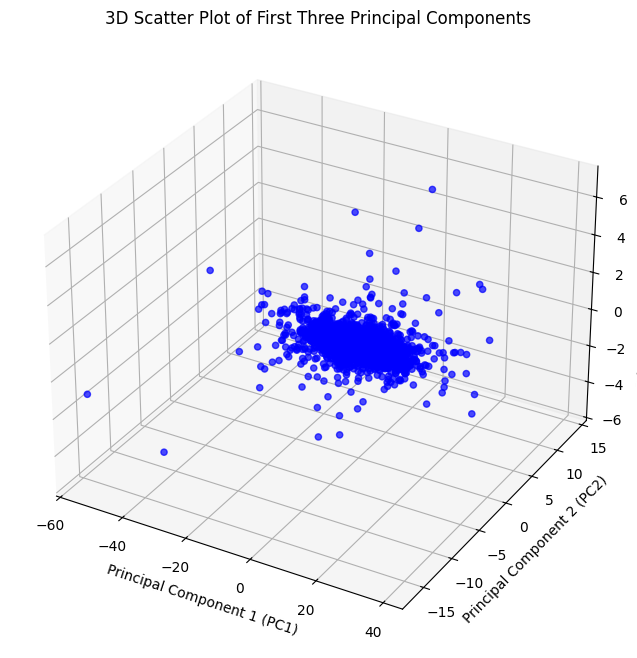

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the first three principal components
ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c='blue', marker='o', alpha=0.7)

ax.set_xlabel('Principal Component 1 (PC1)')
ax.set_ylabel('Principal Component 2 (PC2)')
ax.set_zlabel('Principal Component 3 (PC3)')
ax.set_title('3D Scatter Plot of First Three Principal Components')
ax.grid(True)

plt.show()

### Visualizing PCA Loadings

To understand how each original feature contributes to the principal components, we can visualize the loadings. These loadings are the coefficients of the linear combination of the original variables that form the principal components. A higher absolute value of a loading for a given feature indicates a stronger influence of that feature on the principal component.

/tmp/ipykernel_3769/3838335672.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_names, y=pca.components_[0], palette='viridis')


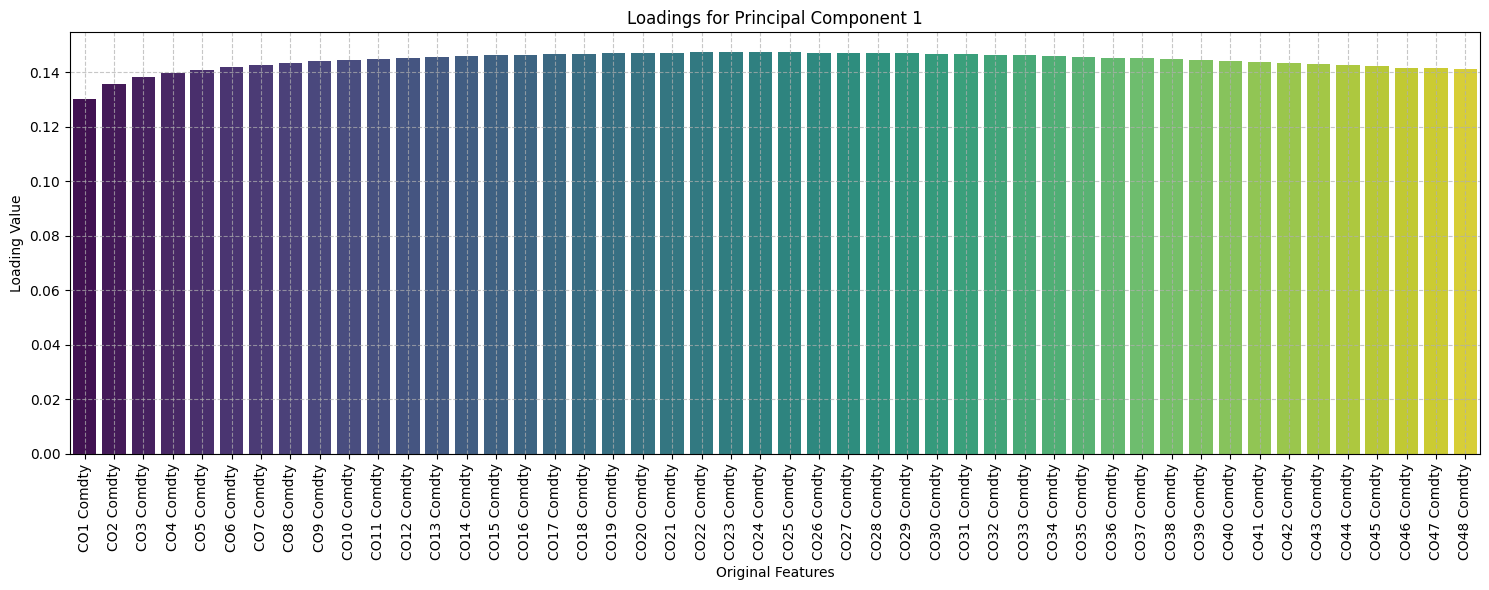

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = logret.columns

# Plot loadings for PC1
plt.figure(figsize=(15, 6))
sns.barplot(x=feature_names, y=pca.components_[0], palette='viridis')
plt.title('Loadings for Principal Component 1')
plt.xlabel('Original Features')
plt.ylabel('Loading Value')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3769/3764254531.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_names, y=pca.components_[1], palette='viridis')


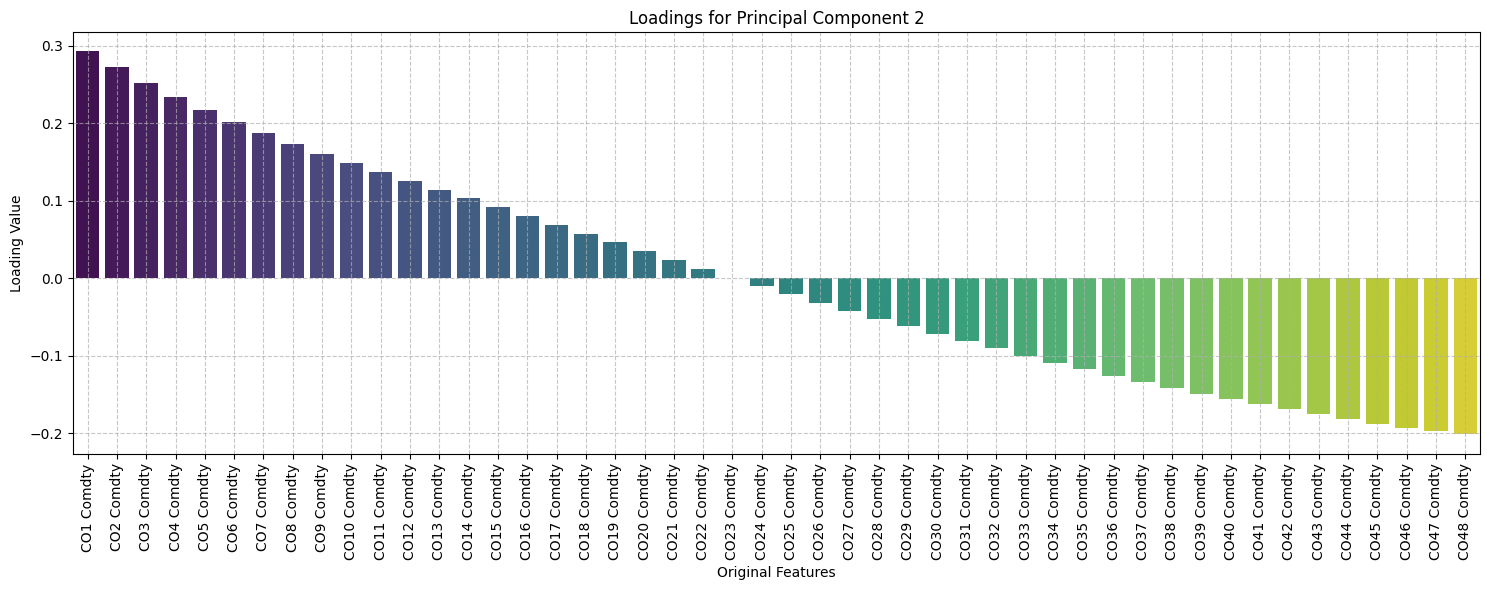

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = logret.columns

# Plot loadings for PC2
plt.figure(figsize=(15, 6))
sns.barplot(x=feature_names, y=pca.components_[1], palette='viridis')
plt.title('Loadings for Principal Component 2')
plt.xlabel('Original Features')
plt.ylabel('Loading Value')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3769/1092880302.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_names, y=pca.components_[2], palette='viridis')


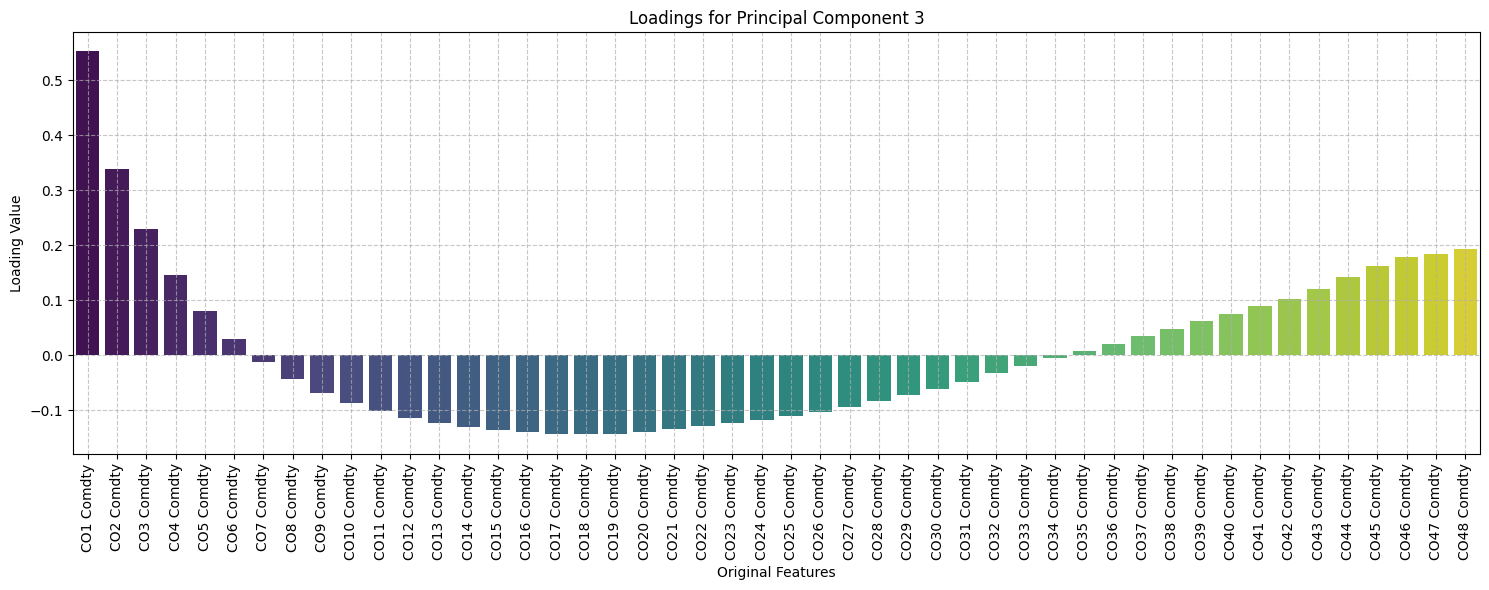

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = logret.columns

# Plot loadings for PC3
plt.figure(figsize=(15, 6))
sns.barplot(x=feature_names, y=pca.components_[2], palette='viridis')
plt.title('Loadings for Principal Component 3')
plt.xlabel('Original Features')
plt.ylabel('Loading Value')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
